In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from nnfabrik.builder import get_data, get_trainer

from sensorium2020_adapted import stacked_core_full_gauss_readout
from wandb_trainer import standard_trainer

random_seed = 42

device = "cuda:7"
torch.cuda.set_device(device)

In [2]:
import os

basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"

# as filenames, we'll select all 7 datasets
filenames = [
    os.path.join(basepath, file) for file in os.listdir(basepath) if ".zip" in file
]

dataset_fn = "sensorium.datasets.static_loaders"
dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": False,
    "include_eye_position": True,
    "batch_size": 128,
    "scale": 0.25,
}

loaders_normalized = get_data(dataset_fn, dataset_config)

dataset_config["exclude"] = "images"

loaders_unnormalized = get_data(dataset_fn, dataset_config)

In [3]:
model_config = {
    "pad_input": False,
    "stack": -1,
    "layers": 4,
    "input_kern": 9,
    "gamma_input": 6.3831,
    "gamma_readout": 0.0076,
    "hidden_kern": 7,
    "hidden_channels": 64,
    "depth_separable": True,
    "grid_mean_predictor": {
        "type": "cortex",
        "input_dimensions": 2,
        "hidden_layers": 1,
        "hidden_features": 30,
        "final_tanh": True,
    },
    "init_sigma": 0.1,
    "init_mu_range": 0.3,
    "gauss_type": "full",
}

model_config['shifter'] = True
model_config['perspective'] = False

model_shifter = stacked_core_full_gauss_readout(loaders_normalized, random_seed, **model_config)

model_config['shifter'] = False
model_config['perspective'] = True

model_perspective = stacked_core_full_gauss_readout(loaders_unnormalized, random_seed, **model_config)

/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/base.py:74: UserWarning: Use of 'gamma_readout' is deprecated. Use 'feature_reg_weight' instead. If 'feature_reg_weight' is defined, 'gamma_readout' is ignored
  warnings.warn(
/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")


In [ ]:
validation_score, trainer_output, state_dict = standard_trainer(
    model_shifter, 
    loaders_normalized, 
    seed=random_seed, 
    max_iter=200, 
    verbose=False, 
    lr_decay_steps=4, 
    avg_loss=False, 
    lr_init=0.009, 
    track_training=False, 
    device=device,
    wandb_project='perspective',
)
validation_score

In [ ]:
validation_score, trainer_output, state_dict = standard_trainer(
    model_perspective, 
    loaders_unnormalized, 
    seed=random_seed, 
    max_iter=200, 
    verbose=False, 
    lr_decay_steps=4, 
    avg_loss=False, 
    lr_init=0.009, 
    track_training=False, 
    device=device,
    wandb_project='perspective',
)
validation_score

In [4]:
from sensorium.utility import get_correlations, get_signal_correlations, get_fev
from sensorium.utility.measure_helpers import get_df_for_scores
import pandas as pd

#model_perspective.eval()

In [6]:
df_persp = pd.read_csv('persp_single_trial.csv')
df_shift = pd.read_csv('shift_single_trial.csv')

In [8]:
persp_single_trial = get_correlations(model_perspective, loaders_unnormalized, tier="test", device=device, as_dict=True)
shift_single_trial = get_correlations(model_shifter, loaders_normalized, tier="test", device=device, as_dict=True)

/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/gaussian.py:582: UserWarning: the specified feature map dimension is not the readout's expected input dimension
  warnings.warn("the specified feature map dimension is not the readout's expected input dimension")


In [9]:
df_persp = get_df_for_scores(
    session_dict=persp_single_trial,
    measure_attribute="Single Trial Correlation"
)
df_shift = get_df_for_scores(
    session_dict=shift_single_trial,
    measure_attribute="Single Trial Correlation"
)
df_persp['group'] = 'perspective'
df_shift['group'] = 'shifter'
df = pd.concat([df_persp, df_shift])

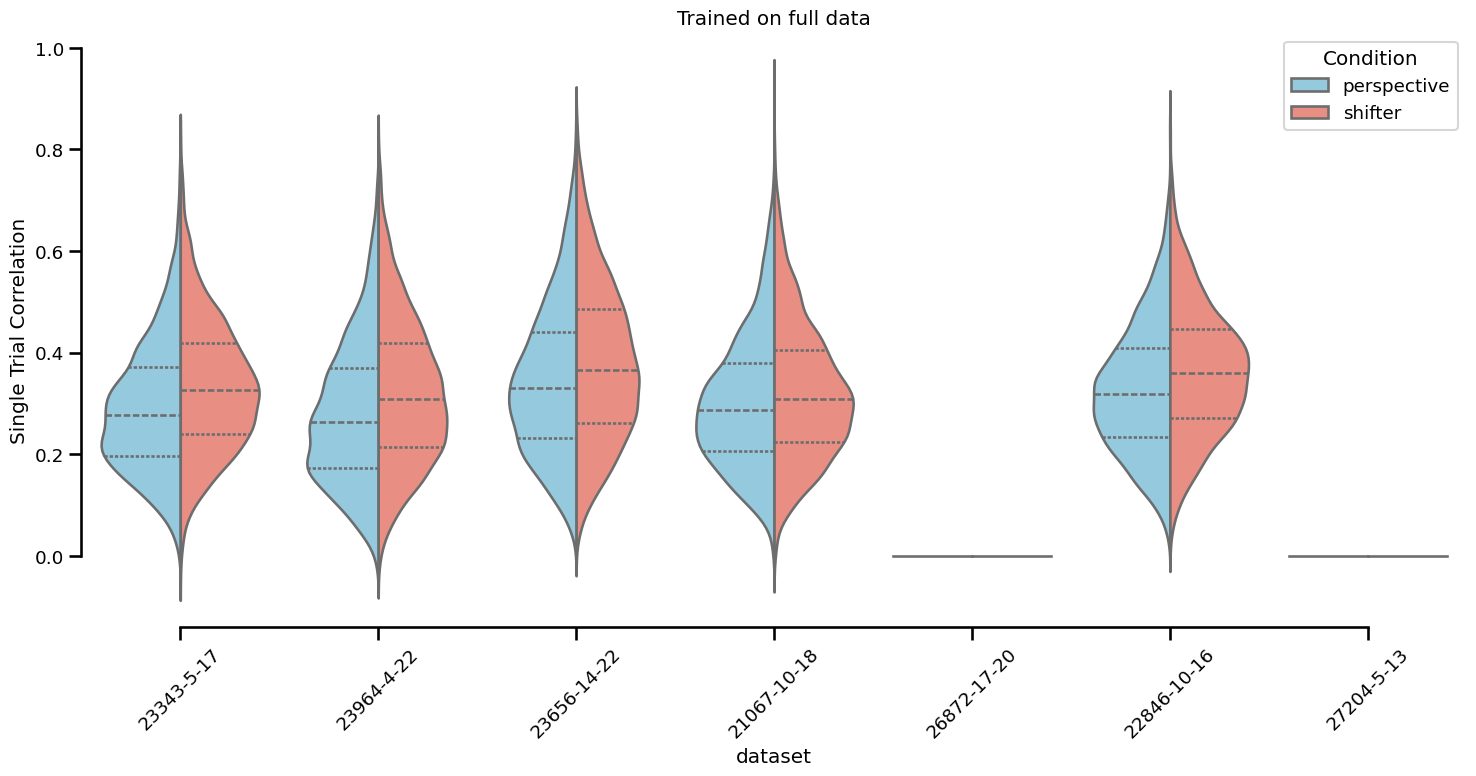

In [32]:
sns.set_context("talk", font_scale=0.8)
plt.figure(figsize=(15, 8))

# Create split violins
ax = sns.violinplot(
    x="dataset", 
    y="Single Trial Correlation", 
    hue="group", 
    data=df,
    split=True,  # ← This creates the asymmetric split
    palette={"perspective": "skyblue", "shifter": "salmon"},
    inner="quartile"  # Show quartile lines inside
)

plt.xticks(rotation=45)
sns.despine(trim=True)
plt.legend(title="Condition")
plt.title('Trained on full data')
plt.tight_layout()

plt.savefig('plots/full_comparison')
plt.show()

In [5]:
columns = ['dataset', 'Single Trial Correlation', 'group']
df_all = pd.DataFrame(columns=columns)

for filename in filenames:
    dataset_config["paths"] = [filename]

    dataset_config["exclude"] = None
    loader_normalized = get_data(dataset_fn, dataset_config)

    dataset_config["exclude"] = "images"
    loader_unnormalized = get_data(dataset_fn, dataset_config)
    

    model_config["shifter"] = False
    model_config["perspective"] = True

    persp_model = stacked_core_full_gauss_readout(loader_unnormalized, random_seed, **model_config)

    model_config["shifter"] = True
    model_config["perspective"] = False

    shift_model = stacked_core_full_gauss_readout(loader_normalized, random_seed, **model_config)

    validation_score, trainer_output, state_dict = standard_trainer(
        persp_model, 
        loader_unnormalized, 
        seed=random_seed, 
        max_iter=200, 
        verbose=False, 
        lr_decay_steps=4, 
        avg_loss=False, 
        lr_init=0.009, 
        track_training=False, 
        device=device,
        wandb_project='perspective',
    )
    print('persp val:', validation_score)

    validation_score, trainer_output, state_dict = standard_trainer(
        shift_model, 
        loader_normalized, 
        seed=random_seed, 
        max_iter=200, 
        verbose=False, 
        lr_decay_steps=4, 
        avg_loss=False, 
        lr_init=0.009, 
        track_training=False, 
        device=device,
        wandb_project='perspective',
    )
    print('shift val:', validation_score)

    persp_single_trial = get_correlations(persp_model, loader_unnormalized, tier="test", device=device, as_dict=True)
    shift_single_trial = get_correlations(shift_model, loader_normalized, tier="test", device=device, as_dict=True)

    df_persp = get_df_for_scores(
        session_dict=persp_single_trial,
        measure_attribute="Single Trial Correlation"
    )
    df_shift = get_df_for_scores(
        session_dict=shift_single_trial,
        measure_attribute="Single Trial Correlation"
    )
    df_persp['group'] = 'perspective'
    df_shift['group'] = 'shifter'
    
    df_all = pd.concat([df_all, df_persp, df_shift], ignore_index=True)
    

/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/base.py:74: UserWarning: Use of 'gamma_readout' is deprecated. Use 'feature_reg_weight' instead. If 'feature_reg_weight' is defined, 'gamma_readout' is ignored
  warnings.warn(
/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: nathan-soeding (nathan-soeding-uni-goettingen) to https://api.wandb.ai. Use `wandb login --relogin` to forc

/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/gaussian.py:582: UserWarning: the specified feature map dimension is not the readout's expected input dimension
  warnings.warn("the specified feature map dimension is not the readout's expected input dimension")
Epoch 84: 100%|██████████| 35/35 [00:03<00:00, 10.17it/s]


final/validation_corr_all,▁
final/validation_corr_mean,▁
val/correlation,▁▄▄▅▅▆▇▇▇▇▇▇▇▇▇█▇███████████████████████
val/poisson_loss,█▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
final/validation_corr_all,0.35391
final/validation_corr_mean,0.35391
val/correlation,0.35376
val/poisson_loss,2186988.0


persp val: 0.3539095


/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


...

/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 86: 100%|██████████| 35/35 [00:03<00:00, 11.64it/s]


final/validation_corr_all,▁
final/validation_corr_mean,▁
val/correlation,▁▂▄▄▄▆▆▆▇▇▇▇▇▇▇▇▇█▇█▇▇██████████████████
val/poisson_loss,█▆▆▅▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
final/validation_corr_all,0.34339
final/validation_corr_mean,0.34339
val/correlation,0.34224
val/poisson_loss,2310879.0


shift val: 0.3433852


/user/nathanpaul.soeding/miniconda3/lib/python3.12/site-packages/neuralpredictors/layers/readouts/gaussian.py:582: UserWarning: the specified feature map dimension is not the readout's expected input dimension
  warnings.warn("the specified feature map dimension is not the readout's expected input dimension")


In [8]:
df_all.to_csv('seperate.csv', index=False)

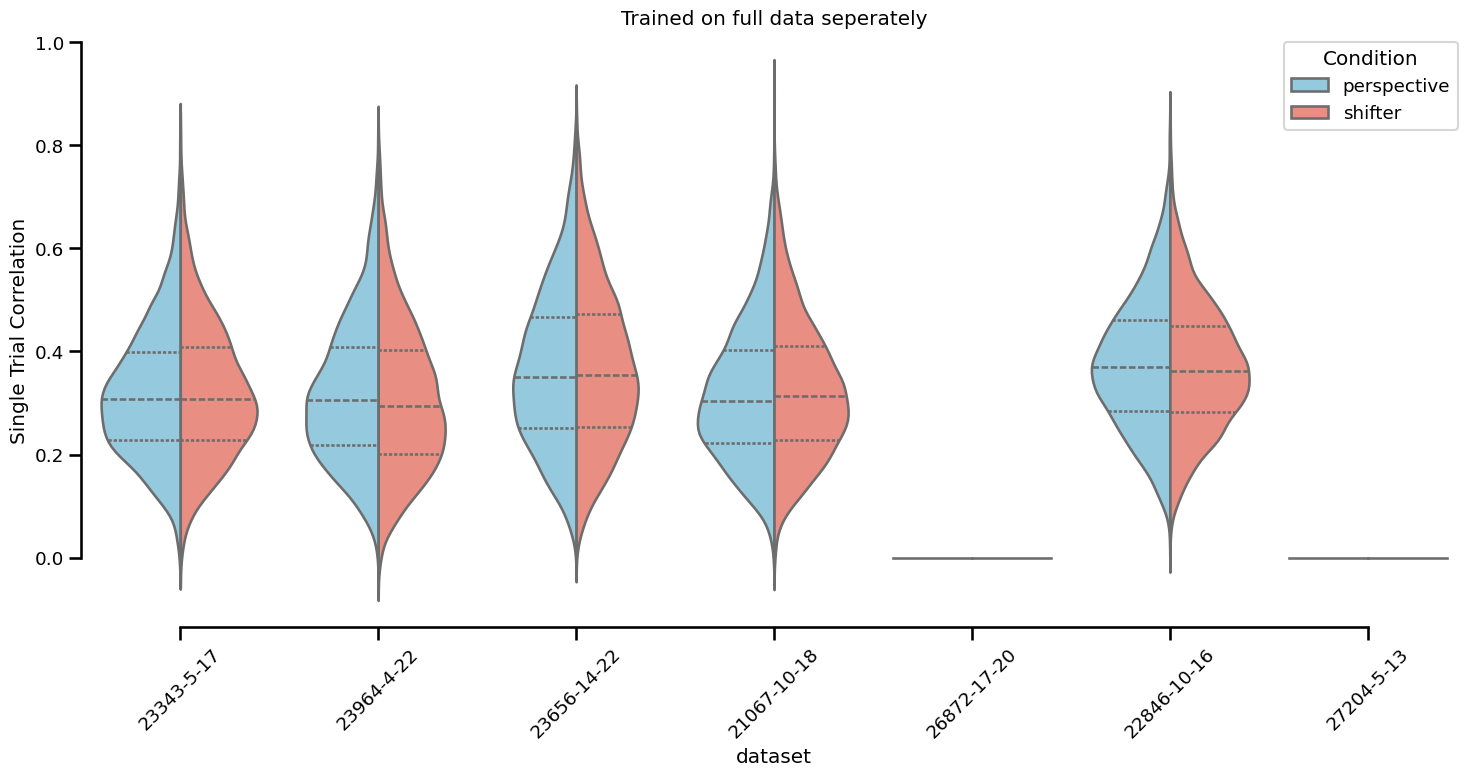

In [11]:
sns.set_context("talk", font_scale=0.8)
plt.figure(figsize=(15, 8))

# Create split violins
ax = sns.violinplot(
    x="dataset", 
    y="Single Trial Correlation", 
    hue="group", 
    data=df_all,
    split=True,  # ← This creates the asymmetric split
    palette={"perspective": "skyblue", "shifter": "salmon"},
    inner="quartile"  # Show quartile lines inside
)

plt.xticks(rotation=45)
sns.despine(trim=True)
plt.legend(title="Condition")
plt.title('Trained on full data seperately')
plt.tight_layout()

plt.savefig('plots/single_comparison')
plt.show()